# GNN Anomaly Detection v7
## Anomaly Detection for EU Bilateral Trade Flows: GNN vs. Classical Methods

**Cells**: A Config · B Load · C Assemble · D Normalise · E Ground Truth · F Adjacency · G GNN · H Classical AD · I GNN Anomaly Scores · J Reconstruction GNN · K Adjacency Comparison · L Evaluation · M Visualisation

In [1]:
# =========================================================
# Cell A — Imports & Configuration
# =========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found — run: pip install torch-geometric")

warnings.filterwarnings("ignore", category=UserWarning)

# ---------------------------------------------------------
# Canonical configuration (must match the pipeline)
# ---------------------------------------------------------

START_MONTH = "2014-01"
END_MONTH   = "2025-11"

MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL",
    "ES", "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]

COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)  # 27

ALL_CATS = [
    "TOTAL",
    "Food_drinks_tobacco",
    "Raw_materials",
    "Energy",
    "Chemicals",
    "Machinery_vehicles",
    "Other_manufactured",
]

N_CATS = len(ALL_CATS)  # 7

CEPII_COLS = [
    "comlang_ethno",
    "contig",
    "smctry",
    "dist",
    "distcap",
    "distw",
    "distwces",
]

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

DATA_DIR = Path(
    "C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN"
)

MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"

IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ---------------------------------------------------------
# Experiment hyperparameters
# ---------------------------------------------------------

HIDDEN_DIM = 64
N_EPOCHS   = 50
LR         = 3e-4
GRAD_CLIP  = 1.0

# TARGET_SCALE computed later (Cell D)

HEADS = 4
K_NEIGHBORS = 6
LOG_NODE_FEATURES = True

# ---------------------------------------------------------
# Anomaly detection
# ---------------------------------------------------------

# Calibration: training residuals used to z-score validation residuals
# Flag anomaly if z-score > threshold

ANOMALY_THRESH = 3.0
SYNTH_MULT     = 5.0   # synthetic anomaly multiplier
N_SYNTH        = 40    # number of injected anomalies

# Known event windows
COVID_WINDOW   = ("2020-04", "2020-09")
UKRAINE_WINDOW = ("2022-03", "2022-12")

# ---------------------------------------------------------
# Sequence / reproducibility
# ---------------------------------------------------------

SEED    = 42
SEQ_LEN = 6

LOG_NODE_FEATURES = True  # (redeclared, harmless)

# ---------------------------------------------------------
# Time splits
# ---------------------------------------------------------

TRAIN_END = pd.Timestamp("2022-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

# ---------------------------------------------------------
# Device
# ---------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device        : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N} | Categories: {N_CATS} | Directed edges: {N*(N-1)}")
print(f"SEQ_LEN: {SEQ_LEN} | LOG_NODE_FEATURES: {LOG_NODE_FEATURES}")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 

✓ PyTorch Geometric available
Device        : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27 | Categories: 7 | Directed edges: 702
SEQ_LEN: 6 | LOG_NODE_FEATURES: True


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs
# Data is already fully clean — no imputation needed.
# ══════════════════════════════════════════════════════════════════════════════

# ── B.1 Trade CSV ─────────────────────────────────────────────────────────────
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
print(f"  Reporters  : {sorted(df_trade['reporter'].unique())}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

# ── B.2 Node feature CSVs (T × 27 each) ──────────────────────────────────────
node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"

node_dfs = {}   # stem → DataFrame(T, 27)
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df

total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
print(f"── Node feature CSVs ──")
print(f"  Files loaded : {len(node_dfs)}")
print(f"  Total NaNs   : {total_node_nans}")
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"  ✓ All clean\n")

# ── B.3 Graph feature CSVs (EURIBOR, VSTOXX — broadcast to all 27 cols) ──────
graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}   # stem → Series(T,)

for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    assert df.std(axis=1).max() < 1e-9, f"{p.name}: columns are not identical broadcasts!"
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)

print(f"── Graph feature CSVs ──")
print(f"  Files loaded : {len(graph_series)}  → {list(graph_series.keys())}\n")

# ── B.4 Edge feature CSV (CEPII bilateral static) ─────────────────────────────
edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
assert edge_csv.exists(), f"Edge feature CSV not found at {edge_csv}"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge feature CSV ──")
print(f"  Shape  : {df_edge.shape}")
print(f"  Cols   : {list(df_edge.columns)}")

── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  Reporters  : ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  NaNs       : 0 ✓

── Node feature CSVs ──
  Files loaded : 35
  Total NaNs   : 0
  ✓ All clean

── Graph feature CSVs ──
  Files loaded : 2  → ['euribor3m_monthly', 'vstoxx_monthly']

── Edge feature CSV ──
  Shape  : (100386, 11)
  Cols   : ['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly
# ══════════════════════════════════════════════════════════════════════════════

# ── C.1 Align all sources to a common monthly index ───────────────────────────
common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

# ── C.2 Node feature tensor (T, N, F_node) ────────────────────────────────────
node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)   # (T, N)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np = np.stack(node_arrays, axis=-1)   # (T, N, F_node)
F_node  = node_np.shape[2]

# ── C.3 Graph feature tensor → broadcast to all nodes ────────────────────────
graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)   # (T, F_graph)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)    # (T, N, F_graph)
node_plus_graph_np = np.concatenate([node_np, graph_broadcast], axis=-1)  # (T, N, F_total)
F_total = node_plus_graph_np.shape[2]

# ── C.4 Target tensor (T, E, C) ───────────────────────────────────────────────
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]   # 702 directed edges
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :]   # (T, E, C)

# ── C.5 Static edge features (E, F_edge) ──────────────────────────────────────
F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]

edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

# ── C.6 Convert to tensors ────────────────────────────────────────────────────
node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)   # (T, N, F_total)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)   # (E, F_edge)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)   # (T, E, C)

print(f"\n✓ Tensor assembly complete")
print(f"  node_feat_tensor : {node_feat_tensor.shape}  (T, N, F_total={F_total})")
print(f"  edge_feat_tensor : {edge_feat_tensor.shape}  (E={E}, F_edge={F_edge})")
print(f"  target_tensor    : {target_tensor.shape}  (T, E, C={N_CATS})")
print(f"  NaNs in node features: {torch.isnan(node_feat_tensor).sum().item()}")
print(f"  NaNs in targets      : {torch.isnan(target_tensor).sum().item()}")

Common time range: 2014-01-01 → 2025-11-01  (T=143)

✓ Tensor assembly complete
  node_feat_tensor : torch.Size([143, 27, 37])  (T, N, F_total=37)
  edge_feat_tensor : torch.Size([702, 7])  (E=702, F_edge=7)
  target_tensor    : torch.Size([143, 702, 7])  (T, E, C=7)
  NaNs in node features: 0
  NaNs in targets      : 868


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Normalisation  (v7: per-node/feature, log-dist edges, computed scale)
# ══════════════════════════════════════════════════════════════════════════════

# D.1 Temporal split (target-based — no boundary leak)
train_idx = [t for t in range(len(common_time)-1) if common_time[t+1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time)-1) if TRAIN_END < common_time[t+1] <= VAL_END]
test_idx  = [t for t in range(len(common_time)-1) if common_time[t+1] > VAL_END]
assert common_time[train_idx[-1]+1] <= TRAIN_END, "boundary leak"
print(f"Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}  ✓ no leak")

# D.2 Optional log-transform of strictly-positive node features
if LOG_NODE_FEATURES:
    train_min = node_feat_tensor[train_idx].reshape(-1, F_total).min(dim=0).values
    log_mask  = (train_min > 0)
    nf_raw    = node_feat_tensor.clone()
    nf_raw[:, :, log_mask] = torch.log1p(node_feat_tensor[:, :, log_mask])
    print(f"Log-transformed {log_mask.sum().item()}/{F_total} positive node features")
else:
    nf_raw, log_mask = node_feat_tensor, None

# D.3 Per-node per-feature z-score (fit on train only)
train_data  = nf_raw[train_idx]
feat_mean   = train_data.mean(dim=0)          # (N, F)
feat_std    = train_data.std(dim=0).clamp(min=1e-8)
node_feat_norm = (nf_raw - feat_mean) / feat_std

# D.4 Edge features: log1p distances → min-max
DISTANCE_FEAT_COLS    = ["dist","distcap","distw","distwces"]
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]
edge_feat_proc = edge_feat_tensor.clone()
for ci in DISTANCE_FEAT_INDICES:
    edge_feat_proc[:, ci] = torch.log1p(edge_feat_proc[:, ci])
emin = edge_feat_proc.min(dim=0).values; emax = edge_feat_proc.max(dim=0).values
edge_feat_norm = (edge_feat_proc - emin) / (emax - emin).clamp(min=1e-8)

# D.5 Target: log1p → 99th-percentile scale (train only)
target_log       = torch.log1p(target_tensor.clamp(min=0))
train_target_log = target_log[train_idx]
valid_train_log  = train_target_log[~torch.isnan(train_target_log)]
TARGET_SCALE     = float(valid_train_log.quantile(0.99))
target_scaled    = target_log / TARGET_SCALE
print(f"TARGET_SCALE = {TARGET_SCALE:.4f}")

# D.6 Detransform helper
def detransform(x):
    t = torch.tensor(x) if not isinstance(x, torch.Tensor) else x
    return torch.expm1(t.clamp(min=-30) * TARGET_SCALE)

# D.7 Train-set residual statistics (populated after GNN training in Cell I)
# Placeholder dicts: {adj_name: ndarray(E, C)}
train_resid_mean = {}
train_resid_std  = {}

print("✓ Normalisation complete")

Train 107 | Val 12 | Test 23  ✓ no leak
Log-transformed 8/37 positive node features
TARGET_SCALE = 21.2947
✓ Normalisation complete


In [7]:
# ============================================================
# Cell E — Ground Truth Anomaly Labels
# ============================================================

# Three label sources combined into a unified binary label array:
# 1. Event labels (real-world disruptions)
# 2. Synthetic labels (injected anomalies)
# 3. Combined labels (union)

n_val = len(val_idx)

# ------------------------------------------------------------
# E.1 Event labels (timestep × edge × category)
# ------------------------------------------------------------

# Energy category index for Ukraine-specific flagging
ENERGY_CAT_IDX = ALL_CATS.index("Energy")

label_event = np.zeros((n_val, E, N_CATS), dtype=bool)

for vi, t in enumerate(val_idx):
    ts = common_time[t + 1]

    # COVID window: all categories, all edges
    if pd.Timestamp(COVID_WINDOW[0]) <= ts <= pd.Timestamp(COVID_WINDOW[1]):
        label_event[vi, :, :] = True

    # Ukraine window: energy category, selected importers
    ENERGY_IMPORTERS = {"DE", "IT", "PL", "FR", "HU", "SK"}

    if pd.Timestamp(UKRAINE_WINDOW[0]) <= ts <= pd.Timestamp(UKRAINE_WINDOW[1]):
        for e_idx, (src_i, dst_i) in enumerate(edge_pairs):
            if COUNTRIES[dst_i] in ENERGY_IMPORTERS:
                label_event[vi, e_idx, ENERGY_CAT_IDX] = True

n_event_labels = int(label_event.sum())

print(f"Event labels: {n_event_labels:,} flagged (edge×category×timestep)")
print(
    f"  COVID window in val period: "
    f"{sum(1 for t in val_idx if pd.Timestamp(COVID_WINDOW[0]) <= common_time[t+1] <= pd.Timestamp(COVID_WINDOW[1]))} steps"
)
print(
    f"  Ukraine window in val period: "
    f"{sum(1 for t in val_idx if pd.Timestamp(UKRAINE_WINDOW[0]) <= common_time[t+1] <= pd.Timestamp(UKRAINE_WINDOW[1]))} steps"
)

# ------------------------------------------------------------
# E.2 Synthetic anomaly injection
# ------------------------------------------------------------

np.random.seed(SEED)

synth_indices = []  # list of (vi, e_idx, c_idx)
label_synth = np.zeros((n_val, E, N_CATS), dtype=bool)

attempts = 0

while len(synth_indices) < N_SYNTH and attempts < N_SYNTH * 20:
    vi = np.random.randint(0, n_val)
    e_idx = np.random.randint(0, E)
    c_idx = np.random.randint(0, N_CATS)

    t = val_idx[vi]

    # Only inject if target is valid and non-trivial
    orig = float(target_scaled[t + 1, e_idx, c_idx])

    if not np.isnan(orig) and orig > 0.05:
        target_scaled[t + 1, e_idx, c_idx] = torch.tensor(orig * SYNTH_MULT)

        synth_indices.append((vi, e_idx, c_idx))
        label_synth[vi, e_idx, c_idx] = True

    attempts += 1

print(
    f"\nSynthetic anomalies injected: {len(synth_indices)}/{N_SYNTH} (seed={SEED})"
)
print(f"  Injection magnitude: ×{SYNTH_MULT} in scaled space")

# ------------------------------------------------------------
# E.3 Combined labels
# ------------------------------------------------------------

label_combined = label_event | label_synth

print(
    f"\nCombined (event ∪ synthetic): "
    f"{int(label_combined.sum()):,} anomalous cells"
)
print(f"  Prevalence: {label_combined.mean() * 100:.2f}%")

# ------------------------------------------------------------
# E.4 Flattened versions for sklearn metrics
# ------------------------------------------------------------

flat_label_synth = label_synth.reshape(-1)
flat_label_event = label_event.reshape(-1)
flat_label_combined = label_combined.reshape(-1)

valid_mask_flat = ~np.isnan(
    target_scaled[
        [val_idx[vi] + 1 for vi in range(n_val)],
        :,
        :
    ].numpy()
).reshape(-1)

print(f"  Valid (non-NaN) evaluation cells: {valid_mask_flat.sum():,}")
print("✓ Ground truth labels ready")

Event labels: 0 flagged (edge×category×timestep)
  COVID window in val period: 0 steps
  Ukraine window in val period: 0 steps

Synthetic anomalies injected: 40/40 (seed=42)
  Injection magnitude: ×5.0 in scaled space

Combined (event ∪ synthetic): 40 anomalous cells
  Prevalence: 0.07%
  Valid (non-NaN) evaluation cells: 58,947
✓ Ground truth labels ready


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — Three Graph Topologies for Anomaly Comparison
#
# For anomaly detection specifically the adjacency matters differently than
# for prediction: the neighbourhood defines what "normal" looks like for each
# node. An edge that appears anomalous relative to the complete graph (which
# averages over all 26 partners) may look even more anomalous relative to the
# CEPII sparse graph (which only shows natural trade partners), because the
# sparse graph has a tighter prior on expected flows.
#
# Three topologies tested:
#   Complete   : all 702 directed pairs (densest, least structured)
#   CEPII-KNN  : K nearest by composite CEPII similarity (geographically informed)
#   Random     : same edge count as CEPII, randomly selected pairs (null baseline)
#
# All edge features remain the actual CEPII features for each (i,j) pair.
# Self-loop policy: GCN/GAT/Transformer get self-loops; SAGE does not.
# ══════════════════════════════════════════════════════════════════════════════

from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv

HAS_PYG = True
EDGE_AWARE_CONVS      = {GATv2Conv, TransformerConv}
CONV_NEEDS_SELF_LOOPS = {GCNConv, GATv2Conv, TransformerConv}
ARCH_LR               = {GCNConv:3e-4, GATv2Conv:1e-4, SAGEConv:3e-4, TransformerConv:1e-4}
HIDDEN_DIM            = 64
HEADS                 = 4

edge_pair_to_idx = {pair: idx for idx, pair in enumerate(edge_pairs)}
edge_index_pred  = torch.tensor(
    [[i for i,j in edge_pairs],[j for i,j in edge_pairs]], dtype=torch.long
)

DISTANCE_FEAT_COLS    = ["dist","distcap","distw","distwces"]
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]

# ── KNN-composite similarity score ────────────────────────────────────────────
composite_score = {}
for e_idx, (i, j) in enumerate(edge_pairs):
    vec = edge_feat_norm[e_idx].clone()
    for ci in DISTANCE_FEAT_INDICES:
        vec[ci] = 1.0 - vec[ci]
    composite_score[(i,j)] = float(vec.mean())

cepii_pairs = []
for i in range(N):
    by_score = sorted([(composite_score.get((i,j),-1.), j) for j in range(N) if i!=j],
                      reverse=True)[:K_NEIGHBORS]
    cepii_pairs.extend([(i,j) for _,j in by_score])
n_sparse = len(cepii_pairs)

# ── Random sparse (one draw, seed=SEED) ───────────────────────────────────────
torch.manual_seed(SEED + 999)
perm_rand  = torch.randperm(len(edge_pairs))[:n_sparse]
rand_pairs = [edge_pairs[k] for k in perm_rand.tolist()]

# ── build_mp_graph ─────────────────────────────────────────────────────────────
def build_mp_graph(pairs, conv_cls):
    ei = torch.tensor([[p[0] for p in pairs],[p[1] for p in pairs]], dtype=torch.long)
    ea = torch.stack([edge_feat_norm[edge_pair_to_idx[p]] for p in pairs])
    if conv_cls in CONV_NEEDS_SELF_LOOPS:
        sl = torch.arange(N, dtype=torch.long)
        ei = torch.cat([ei, torch.stack([sl, sl])], dim=1)
        ea = torch.cat([ea, torch.zeros(N, F_edge)], dim=0)
    return ei, ea

complete_pairs = edge_pairs   # all 702

ADJ_CONFIGS = {
    "Complete" : complete_pairs,
    "CEPII-KNN": cepii_pairs,
    "Random"   : rand_pairs,
}

print("Adjacency edge counts (excl. self-loops):")
for name, pairs in ADJ_CONFIGS.items():
    print(f"  {name:<12}: {len(pairs):4d} edges  "
          f"(avg out-degree {len(pairs)/N:.1f})")
print("✓ Adjacency setup complete")

Adjacency edge counts (excl. self-loops):
  Complete    :  702 edges  (avg out-degree 26.0)
  CEPII-KNN   :  162 edges  (avg out-degree 6.0)
  Random      :  162 edges  (avg out-degree 6.0)
✓ Adjacency setup complete


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — GNN: Prediction Model + Autoencoder Model
#
# PredGNN  : standard link-prediction GNN (trained to predict t+1 flows).
#             Used for prediction-error anomaly scoring.
#
# ReconGNN : graph autoencoder for the current timestep.
#             Encoder: GNN on node features → embeddings H (N, H).
#             Decoder: bilinear + MLP reconstructs target_scaled[t] from H.
#             Used for reconstruction-error anomaly scoring.
#             Literature: DOMINANT (Ding et al. 2019), VGAE (Kipf & Welling 2016).
# ══════════════════════════════════════════════════════════════════════════════
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

def _build_conv(conv_cls, H, heads=4, edge_dim=None):
    # Determine which edge dimension to use
    ed = edge_dim if edge_dim is not None else F_edge
    
    if conv_cls is TransformerConv:
        # TransformerConv does NOT support 'add_self_loops' in __init__
        return conv_cls(
            H, 
            H // heads, 
            heads=heads, 
            edge_dim=ed, 
            concat=True
        )
    
    elif conv_cls is GATv2Conv:
        # GATv2Conv supports 'add_self_loops'
        return conv_cls(
            H, 
            H // heads, 
            heads=heads, 
            edge_dim=ed, 
            concat=True, 
            add_self_loops=False # Managed externally in build_mp_graph
        )
        
    elif conv_cls is GCNConv:
        return conv_cls(H, H, add_self_loops=False)
        
    else:   # SAGEConv
        return conv_cls(H, H)


class PredGNN(nn.Module):
    """Standard prediction GNN — same architecture as v4/v6."""
    def __init__(self, conv_cls, in_ch=37, H=64, n_layers=2,
                 n_out=7, edge_dim=7, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        self.encoder  = nn.Linear(in_ch, H)
        self.convs    = nn.ModuleList([_build_conv(conv_cls, H) for _ in range(n_layers)])
        self.lns      = nn.ModuleList([nn.LayerNorm(H) for _ in range(n_layers)])
        pred_in       = 2*H + edge_dim
        self.decoder  = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H//2),    nn.ReLU(),
            nn.Linear(H//2, n_out)
        )
        self.drop = nn.Dropout(dropout)

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = F.relu(self.encoder(x))
        for conv, ln in zip(self.convs, self.lns):
            r = h
            h = self._conv(conv, h, ei, ea)
            h = ln(h); h = F.relu(h); h = self.drop(h); h = h + r
        return h

    def forward(self, x, ei_mp, ea_mp, ei_pred, ea_pred):
        h = self.encode(x, ei_mp, ea_mp)
        s, d = ei_pred
        return self.decoder(torch.cat([h[s], h[d], ea_pred], dim=-1))


class ReconGNN(nn.Module):
    """
    Graph Autoencoder for reconstruction-based anomaly detection.

    Encoder: 2-layer GNN on node features at time t → H (N, H).
    Decoder: for each directed pair (i,j), reconstructs target_scaled[t, e, :]
             from [H[i] ‖ H[j] ‖ edge_attr(i,j)].

    Anomaly score: reconstruction error at time t (not t+1).
    This captures structural deviations — if a flow at time t cannot be
    reconstructed from the node embeddings, the flow is anomalous relative
    to the graph structure.

    Literature alignment:
      DOMINANT (Ding 2019): uses GCN encoder + attribute reconstruction loss.
      VGAE (Kipf 2016):     uses GCN encoder + link existence reconstruction.
      Here we reconstruct edge-level trade flows (continuous), not binary links.
    """
    def __init__(self, conv_cls, in_ch=37, H=64, n_out=7, edge_dim=7, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        self.encoder  = nn.Linear(in_ch, H)
        self.conv1    = _build_conv(conv_cls, H)
        self.conv2    = _build_conv(conv_cls, H)
        self.ln1      = nn.LayerNorm(H)
        self.ln2      = nn.LayerNorm(H)
        pred_in       = 2*H + edge_dim
        self.recon_head = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H//2),    nn.ReLU(),
            nn.Linear(H//2, n_out)
        )
        self.drop = nn.Dropout(dropout)

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = F.relu(self.encoder(x))
        r = h; h = self._conv(self.conv1, h, ei, ea)
        h = self.ln1(h); h = F.relu(h); h = self.drop(h); h = h + r
        r = h; h = self._conv(self.conv2, h, ei, ea)
        h = self.ln2(h); h = F.relu(h); h = self.drop(h); h = h + r
        return h

    def forward(self, x, ei_mp, ea_mp, ei_pred, ea_pred):
        h   = self.encode(x, ei_mp, ea_mp)
        s,d = ei_pred
        return self.recon_head(torch.cat([h[s], h[d], ea_pred], dim=-1))


print("PredGNN and ReconGNN defined")
for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    m = PredGNN(conv_cls, F_total, HIDDEN_DIM)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  PredGNN / {conv_cls.__name__:<20}: {n:,} params")

PredGNN and ReconGNN defined
  PredGNN / GCNConv             : 22,023 params
  PredGNN / GATv2Conv           : 31,495 params
  PredGNN / SAGEConv            : 30,215 params
  PredGNN / TransformerConv     : 47,879 params


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Classical Anomaly Detection Methods
#
# All methods produce a score array of shape (n_val, E, C): higher = more anomalous.
# All scores are computed in target_scaled space for comparability with GNN scores.
#
# Methods:
#  1. Z-score       : |x - mu_train| / sigma_train   per (edge, cat) series.
#                     Literature: Chandola et al. 2009 (survey).
#  2. IQR fence     : score = max(0, x - Q3_train) / IQR_train  (upper tail only,
#                     since anomalies are typically spikes, not drops).
#  3. EWMA-CUSUM    : exponentially weighted moving average control chart.
#                     Standard in process monitoring (Montgomery 2009).
#                     Score = deviation from EWMA, normalised by in-control std.
#  4. STL residual  : decomposes series into trend + seasonal + remainder via STL.
#                     Score = |remainder| / IQR(train remainder).
#                     Literature: Cleveland et al. 1990; Twitter AnomalyDetection.
#  5. ARIMA residual: ARIMA(1,1,1) fitted on train; score = |forecast error| /
#                     std(train forecast errors). Captures temporal structure.
#  6. IsolationForest: feature vector per (edge, val-step) = [target_t, lag1, lag2,
#                     node_feat_src, node_feat_dst, edge_feat]. Contamination set
#                     to observed anomaly prevalence.
#                     Literature: Liu et al. 2008.
# ══════════════════════════════════════════════════════════════════════════════

import warnings, time
from joblib import Parallel, delayed
from statsmodels.tsa.stl._stl import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

target_np = target_scaled.numpy()   # (T, E, C)
node_np   = node_feat_norm.numpy()
edge_np   = edge_feat_norm.numpy()

train_tgt = [t+1 for t in train_idx]
val_tgt   = [t+1 for t in val_idx]
val_actual= target_np[val_tgt]      # (n_val, E, C)

# ── NaN-fill helper for classical models ──────────────────────────────────────
def fill_series(s):
    s = s.copy().astype(np.float64)
    mask = np.isnan(s)
    if mask.all(): return np.zeros(len(s))
    idx = np.arange(len(s))
    s   = np.interp(idx, idx[~mask], s[~mask])
    return s

# ── 1. Z-score ────────────────────────────────────────────────────────────────
print("1/6  Z-score...")
zscore_scores = np.full((n_val, E, N_CATS), np.nan)
for e in range(E):
    for c in range(N_CATS):
        tr  = target_np[train_tgt, e, c]
        tr  = tr[~np.isnan(tr)]
        if len(tr) < 2: continue
        mu, sig = tr.mean(), tr.std() + 1e-8
        for vi, t in enumerate(val_tgt):
            v = target_np[t, e, c]
            zscore_scores[vi, e, c] = 0.0 if np.isnan(v) else abs((v - mu) / sig)

# ── 2. IQR fence ─────────────────────────────────────────────────────────────
print("2/6  IQR fence...")
iqr_scores = np.full((n_val, E, N_CATS), np.nan)
for e in range(E):
    for c in range(N_CATS):
        tr = target_np[train_tgt, e, c]
        tr = tr[~np.isnan(tr)]
        if len(tr) < 4: continue
        Q1, Q3 = np.percentile(tr, 25), np.percentile(tr, 75)
        IQR    = Q3 - Q1 + 1e-8
        for vi, t in enumerate(val_tgt):
            v = target_np[t, e, c]
            iqr_scores[vi, e, c] = 0.0 if np.isnan(v) else max(0.0, (v - Q3) / IQR)

# ── 3. EWMA-CUSUM ─────────────────────────────────────────────────────────────
print("3/6  EWMA-CUSUM...")
def fit_ewma(e, c, alpha=0.3):
    full = target_np[:, e, c]
    full = fill_series(full)
    # Compute EWMA on training portion
    ewma = np.zeros(len(full))
    ewma[0] = full[0]
    for i in range(1, len(full)):
        ewma[i] = alpha * full[i] + (1-alpha) * ewma[i-1]
    resid_tr = full[train_tgt] - ewma[train_tgt]
    sigma    = resid_tr.std() + 1e-8
    scores_v = [abs((full[t] - ewma[t]) / sigma) for t in val_tgt]
    return e, c, scores_v

ewma_scores = np.full((n_val, E, N_CATS), np.nan)
for e, c, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_ewma)(e, c) for e in range(E) for c in range(N_CATS)):
    ewma_scores[:, e, c] = sc
print("   done")

# ── 4. STL residual ───────────────────────────────────────────────────────────
print("4/6  STL residual (parallel)...")
def fit_stl(e, c):
    full = fill_series(target_np[:, e, c])
    if np.std(full) < 1e-8:
        return e, c, [0.0]*n_val
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res     = STL(full, period=12, robust=True).fit()
            remain  = res.resid
            tr_rem  = remain[train_tgt]
            tr_iqr  = np.percentile(tr_rem, 75) - np.percentile(tr_rem, 25) + 1e-8
            scores_v= [abs(remain[t]) / tr_iqr for t in val_tgt]
    except Exception:
        scores_v = [0.0]*n_val
    return e, c, scores_v

stl_scores = np.full((n_val, E, N_CATS), np.nan)
t0 = time.time()
for e, c, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_stl)(e, c) for e in range(E) for c in range(N_CATS)):
    stl_scores[:, e, c] = sc
print(f"   done  {time.time()-t0:.1f}s")

# ── 5. ARIMA residual ─────────────────────────────────────────────────────────
print("5/6  ARIMA residual (parallel)...")
def fit_arima_resid(e, c):
    tr_s = fill_series(target_np[train_tgt, e, c])
    if np.std(tr_s) < 1e-8:
        return e, c, [0.0]*n_val
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit      = SARIMAX(tr_s, order=(1,1,1), trend='n',
                               enforce_stationarity=False,
                               enforce_invertibility=False).fit(
                                   disp=False, maxiter=100, method='lbfgs')
            tr_resid = fit.resid
            sigma    = tr_resid.std() + 1e-8
            forecasts= list(fit.forecast(n_val))
            scores_v = []
            for vi, t in enumerate(val_tgt):
                v = target_np[t, e, c]
                scores_v.append(0.0 if np.isnan(v) else abs((v - forecasts[vi]) / sigma))
    except Exception:
        scores_v = [0.0]*n_val
    return e, c, scores_v

arima_scores = np.full((n_val, E, N_CATS), np.nan)
t0 = time.time()
for e, c, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_arima_resid)(e, c) for e in range(E) for c in range(N_CATS)):
    arima_scores[:, e, c] = sc
print(f"   done  {time.time()-t0:.1f}s")

# ── 6. Isolation Forest ───────────────────────────────────────────────────────
print("6/6  IsolationForest (per-edge)...")
def fit_iforest(e):
    src_i, dst_i = edge_pairs[e]
    rows_tr, rows_va = [], []
    for t in train_tgt:
        tgt_row = target_np[t, e, :]
        if np.isnan(tgt_row).any(): continue
        lag1 = target_np[max(0,t-1), e, :]
        lag2 = target_np[max(0,t-2), e, :]
        feat = np.concatenate([tgt_row, lag1, lag2,
                               node_np[t-1,src_i], node_np[t-1,dst_i], edge_np[e]])
        rows_tr.append(np.nan_to_num(feat))
    for t in val_tgt:
        lag1 = target_np[max(0,t-1), e, :]
        lag2 = target_np[max(0,t-2), e, :]
        feat = np.concatenate([target_np[t,e,:], lag1, lag2,
                               node_np[t-1,src_i], node_np[t-1,dst_i], edge_np[e]])
        rows_va.append(np.nan_to_num(feat))
    if len(rows_tr) < 10 or len(rows_va) == 0:
        return e, np.zeros(n_val)
    sc = StandardScaler().fit(rows_tr)
    clf = IsolationForest(n_estimators=100, contamination=0.05,
                          random_state=SEED).fit(sc.transform(rows_tr))
    # decision_function: higher = more normal → negate for anomaly score
    scores_v = -clf.decision_function(sc.transform(rows_va))
    return e, scores_v

iforest_scores_raw = np.full((n_val, E), np.nan)
t0 = time.time()
for e, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_iforest)(e) for e in range(E)):
    iforest_scores_raw[:, e] = sc
# Broadcast to (n_val, E, C) — IForest is per-edge (all categories together)
iforest_scores = np.repeat(iforest_scores_raw[:,:,np.newaxis], N_CATS, axis=2)
print(f"   done  {time.time()-t0:.1f}s")

classical_scores = {
    "Z-score"     : zscore_scores,
    "IQR-fence"   : iqr_scores,
    "EWMA-CUSUM"  : ewma_scores,
    "STL-resid"   : stl_scores,
    "ARIMA-resid" : arima_scores,
    "IsoForest"   : iforest_scores,
}
print("\n✓ Classical anomaly detectors complete")

1/6  Z-score...
2/6  IQR fence...
3/6  EWMA-CUSUM...
   done
4/6  STL residual (parallel)...
   done  108.6s
5/6  ARIMA residual (parallel)...
   done  614.2s
6/6  IsolationForest (per-edge)...
   done  150.8s

✓ Classical anomaly detectors complete


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — GNN Prediction-Error Anomaly Scoring
#
# Design (literature-grounded):
#   Step 1. Train PredGNN on training data → learn P(target[t+1] | graph[t]).
#   Step 2. Compute training residuals: resid_train[t,e,c] = actual[t+1,e,c]
#           - pred[t,e,c] for each training step.
#   Step 3. Fit per-(edge,category) calibration stats: mu[e,c], sigma[e,c]
#           from training residuals (NOT val residuals — no information leakage).
#   Step 4. Val anomaly score[t,e,c] = |resid_val[t,e,c] - mu[e,c]| / sigma[e,c].
#
# This is the graph-structured extension of ARIMA-residual anomaly detection,
# and is equivalent to the LSTM-AD (Malhotra et al. 2015) approach adapted
# for GNNs: "anomaly = deviation from the model's learned normality".
#
# Calibrating by training residuals (not raw values) is critical: it removes
# the edge-level baseline error (some edges are inherently noisier) so that
# the score measures *unexpected* deviation, not just large values.
#
# The best architecture from v4 (TransformerConv / CEPII-KNN) is used here.
# Adjacency comparison (complete vs CEPII vs random) is done in Cell K.
# ══════════════════════════════════════════════════════════════════════════════

BEST_CONV = TransformerConv   # from v4 results; change if your run differs
BEST_ADJ  = "CEPII-KNN"

def train_pred_gnn(conv_cls, adj_name, n_epochs=N_EPOCHS, verbose=True):
    """Train PredGNN; return (model, calibration_mu, calibration_sigma)."""
    pairs        = ADJ_CONFIGS[adj_name]
    lr           = ARCH_LR[conv_cls]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_mp_d  = ei_mp.to(DEVICE); ea_mp_d  = ea_mp.to(DEVICE)
    ei_pred_d= edge_index_pred.to(DEVICE)
    ea_pred_d= edge_feat_norm.to(DEVICE)

    torch.manual_seed(SEED)
    model = PredGNN(conv_cls, F_total, HIDDEN_DIM, n_layers=2,
                    n_out=N_CATS, edge_dim=F_edge).to(DEVICE)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()

    for epoch in range(1, n_epochs+1):
        model.train()
        for t in train_idx:
            x     = node_feat_norm[t].to(DEVICE)
            y     = target_scaled[t+1].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
        if verbose and epoch % 10 == 0:
            model.eval()
            v = 0.
            with torch.no_grad():
                for t in val_idx:
                    x = node_feat_norm[t].to(DEVICE)
                    y = target_scaled[t+1].to(DEVICE)
                    valid = ~torch.isnan(y).any(dim=-1)
                    pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                    v += crit(pred[valid], y[valid]).item()
            print(f"  epoch {epoch:3d}  val={v/len(val_idx):.5f}")

    # ── Calibration: training residuals ────────────────────────────────────────
    model.eval()
    resid_train = np.full((len(train_idx), E, N_CATS), np.nan)
    with torch.no_grad():
        for i, t in enumerate(train_idx):
            x    = node_feat_norm[t].to(DEVICE)
            pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d).cpu().numpy()
            act  = target_scaled[t+1].numpy()
            resid_train[i] = act - pred   # actual minus predicted

    # Per-(edge, category) mean and std of training residuals
    calib_mu  = np.nanmean(resid_train, axis=0)   # (E, C)
    calib_sig = np.nanstd(resid_train, axis=0) + 1e-8

    return model, calib_mu, calib_sig, ei_mp_d, ea_mp_d


def gnn_anomaly_scores(model, calib_mu, calib_sig, ei_mp_d, ea_mp_d):
    """
    Compute calibrated anomaly scores on the validation set.
    Returns:
      raw_resid  (n_val, E, C): actual - predicted (raw residuals)
      z_scores   (n_val, E, C): |raw_resid - calib_mu| / calib_sig
    """
    model.eval()
    ei_pred_d = edge_index_pred.to(DEVICE)
    ea_pred_d = edge_feat_norm.to(DEVICE)

    raw_resid = np.full((n_val, E, N_CATS), np.nan)
    with torch.no_grad():
        for vi, t in enumerate(val_idx):
            x     = node_feat_norm[t].to(DEVICE)
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d).cpu().numpy()
            act   = target_scaled[t+1].numpy()
            raw_resid[vi] = act - pred

    z_scores = np.abs(raw_resid - calib_mu) / calib_sig   # (n_val, E, C)
    return raw_resid, z_scores


print(f"Training PredGNN ({BEST_CONV.__name__}, {BEST_ADJ})...")
pred_model, calib_mu, calib_sig, ei_best_d, ea_best_d = train_pred_gnn(
    BEST_CONV, BEST_ADJ, n_epochs=N_EPOCHS, verbose=True
)
raw_resid_pred, z_scores_pred = gnn_anomaly_scores(
    pred_model, calib_mu, calib_sig, ei_best_d, ea_best_d
)

print(f"\nVal z-score stats (GNN Prediction):")
valid_z = z_scores_pred[~np.isnan(z_scores_pred)]
print(f"  Mean={valid_z.mean():.3f}  95th pct={np.percentile(valid_z,95):.3f}  "
      f"Max={valid_z.max():.3f}")
print(f"  Flagged at z>{ANOMALY_THRESH}: "
      f"{(valid_z > ANOMALY_THRESH).sum():,} cells  "
      f"({(valid_z > ANOMALY_THRESH).mean()*100:.2f}%)")

gnn_scores = {"PredGNN-" + BEST_ADJ: z_scores_pred}
print("✓ GNN prediction-error anomaly scoring complete")

Training PredGNN (TransformerConv, CEPII-KNN)...
  epoch  10  val=0.03006
  epoch  20  val=0.02888
  epoch  30  val=0.02518
  epoch  40  val=0.02752
  epoch  50  val=0.01892

Val z-score stats (GNN Prediction):
  Mean=1.790  95th pct=4.589  Max=153.393
  Flagged at z>3.0: 9,893 cells  (16.78%)
✓ GNN prediction-error anomaly scoring complete


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell J — Reconstruction-Based GNN Anomaly Detection
#
# Design (DOMINANT-inspired, Ding et al. 2019):
#   The ReconGNN is trained to reconstruct target_scaled[t] (current timestep,
#   not next) from the GNN-encoded node embeddings.
#   Training loss = MSE(recon[t], actual[t]).
#   Val anomaly score = calibrated reconstruction error.
#
# Key distinction from prediction-based:
#   Prediction error  → detects anomalies relative to temporal trend.
#   Reconstruction error → detects anomalies relative to graph structure.
#   A flow that is consistent with its temporal trend but inconsistent with
#   its graph neighbours will score high on reconstruction but not prediction.
#
# Combined score (ensemble):
#   score_combined = 0.5 * z_pred + 0.5 * z_recon
#   This hedges between temporal and structural anomaly signals.
# ══════════════════════════════════════════════════════════════════════════════

def train_recon_gnn(conv_cls, adj_name, n_epochs=N_EPOCHS, verbose=True):
    pairs        = ADJ_CONFIGS[adj_name]
    lr           = ARCH_LR[conv_cls]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_mp_d  = ei_mp.to(DEVICE); ea_mp_d  = ea_mp.to(DEVICE)
    ei_pred_d= edge_index_pred.to(DEVICE)
    ea_pred_d= edge_feat_norm.to(DEVICE)

    torch.manual_seed(SEED + 1)
    model = ReconGNN(conv_cls, F_total, HIDDEN_DIM,
                     n_out=N_CATS, edge_dim=F_edge).to(DEVICE)
    opt   = Adam(model.parameters(), lr=ARCH_LR[conv_cls], weight_decay=1e-5)
    crit  = nn.MSELoss()

    for epoch in range(1, n_epochs+1):
        model.train()
        for t in train_idx:
            x     = node_feat_norm[t].to(DEVICE)
            # Target: reconstruct CURRENT timestep (not t+1)
            y     = target_scaled[t].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            if not valid.any(): continue
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
        if verbose and epoch % 10 == 0:
            model.eval()
            v = 0.
            with torch.no_grad():
                for t in val_idx:
                    x = node_feat_norm[t].to(DEVICE)
                    y = target_scaled[t].to(DEVICE)
                    valid = ~torch.isnan(y).any(dim=-1)
                    if not valid.any(): continue
                    pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                    v += crit(pred[valid], y[valid]).item()
            print(f"  epoch {epoch:3d}  val={v/len(val_idx):.5f}")

    # Calibration on training set (current-step reconstruction)
    model.eval()
    resid_tr = np.full((len(train_idx), E, N_CATS), np.nan)
    with torch.no_grad():
        for i, t in enumerate(train_idx):
            x    = node_feat_norm[t].to(DEVICE)
            pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d).cpu().numpy()
            act  = target_scaled[t].numpy()
            resid_tr[i] = act - pred

    rc_mu  = np.nanmean(resid_tr, axis=0)
    rc_sig = np.nanstd(resid_tr, axis=0) + 1e-8

    # Val scores
    resid_va = np.full((n_val, E, N_CATS), np.nan)
    with torch.no_grad():
        for vi, t in enumerate(val_idx):
            x    = node_feat_norm[t].to(DEVICE)
            pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d).cpu().numpy()
            act  = target_scaled[t].numpy()
            resid_va[vi] = act - pred

    z_recon = np.abs(resid_va - rc_mu) / rc_sig
    return model, z_recon


print(f"Training ReconGNN ({BEST_CONV.__name__}, {BEST_ADJ})...")
recon_model, z_scores_recon = train_recon_gnn(BEST_CONV, BEST_ADJ, verbose=True)

# ── Ensemble score ─────────────────────────────────────────────────────────────
z_scores_ensemble = 0.5 * z_scores_pred + 0.5 * z_scores_recon

gnn_scores["ReconGNN-" + BEST_ADJ]    = z_scores_recon
gnn_scores["Ensemble-"  + BEST_ADJ]   = z_scores_ensemble

valid_zr = z_scores_recon[~np.isnan(z_scores_recon)]
print(f"\nReconGNN z-score: Mean={valid_zr.mean():.3f}  95th={np.percentile(valid_zr,95):.3f}")
print("✓ Reconstruction GNN and ensemble scores complete")

Training ReconGNN (TransformerConv, CEPII-KNN)...
  epoch  10  val=0.03040
  epoch  20  val=0.04114
  epoch  30  val=0.04986
  epoch  40  val=0.02117
  epoch  50  val=0.02491

ReconGNN z-score: Mean=2.202  95th=5.642
✓ Reconstruction GNN and ensemble scores complete


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Quick Fix: Inject a test event into the validation window
# ══════════════════════════════════════════════════════════════════════════════

# Check if the validation period has any real-world events
# label_event is already sized (12, E, C) for the validation window
if label_event.sum() == 0:
    print("No events found in the validation window. Injecting a mock macro-event...")
    
    # Pick a relative month in the validation window (e.g., the 2nd and 3rd months)
    # Let's simulate a geopolitical trade shock affecting the first 15 trade edges
    # We will flag the 'TOTAL' category (index 0) as anomalous for these edges
    label_event[1:3, 0:15, 0] = True
    
    print(f"✓ Injected {label_event.sum()} positive labels into `label_event` for testing.")
else:
    print(f"Validation window already has {label_event.sum()} positive events.")

No events found in the validation window. Injecting a mock macro-event...
✓ Injected 30 positive labels into `label_event` for testing.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell K — Adjacency Comparison for Anomaly Detection
#
# Trains PredGNN (prediction-error anomaly scorer) on each of the three
# adjacency structures.  Evaluates:
#   1. AUROC on synthetic labels  (clean ground truth)
#   2. AUROC on event labels      (real-world events, soft ground truth)
#   3. Val prediction MSE         (predictive performance — secondary metric)
#
# Hypothesis: CEPII-KNN > Random > Complete for anomaly AUROC.
#   Reasoning: the sparse geographically informed graph creates a tighter
#   normality prior. Flows outside the expected geographic network are more
#   visible as anomalies. The complete graph averages over all 26 partners,
#   diluting the signal. Random has no structure, so deviations from its
#   normality prior are arbitrary — expected to perform worst.
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import numpy as np
import torch
import torch.nn as nn
import warnings

def evaluate_scores(score_arr, label_arr, threshold=ANOMALY_THRESH):
    """
    score_arr: (n_val, E, C)
    label_arr: (n_val, E, C) bool
    Returns: {auroc, auprc, f1_at_thresh, n_flagged}
    """
    flat_scores = score_arr.reshape(-1)
    flat_labels = label_arr.reshape(-1).astype(int)
    
    # Mask NaNs
    valid = ~np.isnan(flat_scores)
    s = flat_scores[valid]; l = flat_labels[valid]
    
    # Handle cases with no positive labels or only positive labels
    if l.sum() == 0 or l.sum() == len(l):
        if l.sum() == 0:
            print("    [Warning] No positive labels found in this period. Metrics will be N/A.")
        return {"auroc": np.nan, "auprc": np.nan, "f1": np.nan, "flagged": 0}
        
    # Clip extreme scores for numerical stability
    s_clip = np.clip(s, 0, np.percentile(s[s<np.inf], 99.9))
    auroc  = roc_auc_score(l, s_clip)
    auprc  = average_precision_score(l, s_clip)
    pred_b = (s >= threshold).astype(int)
    f1     = f1_score(l, pred_b, zero_division=0)
    
    return {"auroc": auroc, "auprc": auprc, "f1": f1, "flagged": int((s >= threshold).sum())}

def safe_fmt(val, precision=4):
    """Safely format metrics, replacing NaNs with 'N/A' to avoid printing 'nan'"""
    if np.isnan(val):
        return "N/A   "
    return f"{val:.{precision}f}"

adj_anomaly_results = {}

for adj_name in ADJ_CONFIGS:
    print(f"\n── Adjacency: {adj_name} ──")
    model, c_mu, c_sig, ei_d, ea_d = train_pred_gnn(
        BEST_CONV, adj_name, n_epochs=N_EPOCHS, verbose=False
    )
    _, z_sc = gnn_anomaly_scores(model, c_mu, c_sig, ei_d, ea_d)

    # Val MSE (secondary — predictive performance)
    model.eval()
    v_loss = 0.
    ei_pred_d = edge_index_pred.to(DEVICE); ea_pred_d = edge_feat_norm.to(DEVICE)
    crit = nn.MSELoss()
    with torch.no_grad():
        for t in val_idx:
            x = node_feat_norm[t].to(DEVICE); y = target_scaled[t+1].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            pred  = model(x, ei_d, ea_d, ei_pred_d, ea_pred_d)
            v_loss += crit(pred[valid], y[valid]).item()
    val_mse = v_loss / len(val_idx)

    eval_synth = evaluate_scores(z_sc, label_synth)
    eval_event = evaluate_scores(z_sc, label_event)

    adj_anomaly_results[adj_name] = {
        "z_scores"   : z_sc,
        "val_mse"    : val_mse,
        "synth"      : eval_synth,
        "event"      : eval_event,
    }
    
    print(f"  Val MSE        : {val_mse:.5f}")
    print(f"  Synth AUROC    : {safe_fmt(eval_synth['auroc'])}  AUPRC={safe_fmt(eval_synth['auprc'])}  F1={safe_fmt(eval_synth['f1'])}")
    print(f"  Event AUROC    : {safe_fmt(eval_event['auroc'])}  AUPRC={safe_fmt(eval_event['auprc'])}  F1={safe_fmt(eval_event['f1'])}")

gnn_scores.update({f"PredGNN-{k}": adj_anomaly_results[k]["z_scores"]
                   for k in ADJ_CONFIGS})
print("\n✓ Adjacency comparison complete")


── Adjacency: Complete ──
  Val MSE        : 0.02274
  Synth AUROC    : 0.9998  AUPRC=0.6525  F1=0.0380
  Event AUROC    : 0.5700  AUPRC=0.0007  F1=0.0010

── Adjacency: CEPII-KNN ──
  Val MSE        : 0.01909
  Synth AUROC    : 0.9997  AUPRC=0.6108  F1=0.0102
  Event AUROC    : 0.5747  AUPRC=0.0006  F1=0.0008

── Adjacency: Random ──
  Val MSE        : 0.02244
  Synth AUROC    : 0.9998  AUPRC=0.6542  F1=0.1810
  Event AUROC    : 0.3601  AUPRC=0.0004  F1=0.0000

✓ Adjacency comparison complete


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell L — Full Anomaly Detection Evaluation
#
# Evaluates all classical + GNN methods on:
#   1. Synthetic labels  (exact ground truth, strong evaluation)
#   2. Event labels      (COVID + Ukraine, soft ground truth)
#   3. Combined labels   (union)
#
# Per-category and per-country breakdowns for the best GNN method.
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_curve, precision_recall_curve
import numpy as np

all_scores = {**classical_scores, **gnn_scores}

# ── L.1 Master evaluation table ───────────────────────────────────────────────
print("═"*100)
print("  ANOMALY DETECTION EVALUATION")
print(f"  AUROC / AUPRC / F1@{ANOMALY_THRESH}z")
print("═"*100)
header = f"{'Method':<28}  {'Synth AUROC':>11}  {'Synth AUPRC':>11}  {'Synth F1':>9}  " \
         f"{'Event AUROC':>11}  {'Event AUPRC':>11}  {'Event F1':>9}"
print(header); print("─"*100)

def safe_fmt(val):
    return f"{val:>11.4f}" if not np.isnan(val) else f"{'N/A':>11}"

eval_results = {}
for name, sc_arr in sorted(all_scores.items()):
    synth_r = evaluate_scores(sc_arr, label_synth)
    event_r = evaluate_scores(sc_arr, label_event)
    eval_results[name] = {"synth": synth_r, "event": event_r}
    print(f"  {name:<26}  "
          f"{safe_fmt(synth_r['auroc'])}  {safe_fmt(synth_r['auprc'])}  {safe_fmt(synth_r['f1'])[-9:]}  "
          f"{safe_fmt(event_r['auroc'])}  {safe_fmt(event_r['auprc'])}  {safe_fmt(event_r['f1'])[-9:]}")
print("═"*100)

# Filter out N/A values before finding the best method to avoid crashing
valid_synth = {k: v for k, v in eval_results.items() if not np.isnan(v["synth"]["auroc"])}
valid_event = {k: v for k, v in eval_results.items() if not np.isnan(v["event"]["auroc"])}

if valid_synth:
    best_synth = max(valid_synth, key=lambda x: valid_synth[x]["synth"]["auroc"])
    print(f"  Best on synthetic: {best_synth}  (AUROC={valid_synth[best_synth]['synth']['auroc']:.4f})")
else:
    best_synth = "Z-score" # Fallback

if valid_event:
    best_event = max(valid_event, key=lambda x: valid_event[x]["event"]["auroc"])
    print(f"  Best on events   : {best_event}  (AUROC={valid_event[best_event]['event']['auroc']:.4f})")

# ── L.2 Per-category anomaly performance (best GNN method) ────────────────────
# Fallback if Ensemble isn't found
best_gnn_score = gnn_scores.get(f"Ensemble-{BEST_ADJ}", list(gnn_scores.values())[0] if gnn_scores else np.zeros_like(label_synth))

print(f"\nPer-category AUROC (Best GNN, synthetic labels):")
for c, cat in enumerate(ALL_CATS):
    sc_c = best_gnn_score[:, :, c].reshape(-1)
    lb_c = label_synth[:, :, c].reshape(-1).astype(int)
    valid = ~np.isnan(sc_c); s = sc_c[valid]; l = lb_c[valid]
    auc = roc_auc_score(l, np.clip(s, 0, np.percentile(s,99.9))) if l.sum()>0 else np.nan
    auc_str = f"{auc:.4f}" if not np.isnan(auc) else "N/A"
    print(f"  {cat:<28}: AUROC = {auc_str}")

# ── L.3 Per-country anomaly performance ───────────────────────────────────────
print(f"\nPer-country AUROC (Best GNN, synthetic labels):")
country_aucs = {}
for ci, country in enumerate(COUNTRIES):
    edges_i = [e for e,(s,d) in enumerate(edge_pairs) if s==ci or d==ci]
    sc_c    = best_gnn_score[:, edges_i, :].reshape(-1)
    lb_c    = label_synth[:, edges_i, :].reshape(-1).astype(int)
    valid   = ~np.isnan(sc_c); s = sc_c[valid]; l = lb_c[valid]
    auc = roc_auc_score(l, np.clip(s, 0, np.percentile(s,99.9))) if l.sum()>0 else np.nan
    country_aucs[country] = auc

# Fix: Safely handle np.nan in sorting and bar generation
for country, auc in sorted(country_aucs.items(), key=lambda x: -1 if np.isnan(x[1]) else -x[1]):
    safe_auc = 0 if np.isnan(auc) else auc
    bar = "█" * int(safe_auc * 20)
    auc_str = f"{auc:.4f}" if not np.isnan(auc) else "N/A   "
    print(f"  {country:<15}: {auc_str}  {bar}")

# Store ROC curves for plotting
roc_curves = {}
flat_label_synth = label_synth.reshape(-1)
for name in [best_synth, "Z-score", "ARIMA-resid", "STL-resid", "IsoForest"]:
    if name not in all_scores: continue
    sc  = all_scores[name].reshape(-1)
    lb  = flat_label_synth.astype(int)
    ok  = ~np.isnan(sc)
    # Only calculate ROC curve if there are positive labels
    if lb[ok].sum() > 0:
        fpr, tpr, _ = roc_curve(lb[ok], np.clip(sc[ok],0,np.percentile(sc[ok],99.9)))
        roc_curves[name] = (fpr, tpr)

print("\n✓ Evaluation complete")

════════════════════════════════════════════════════════════════════════════════════════════════════
  ANOMALY DETECTION EVALUATION
  AUROC / AUPRC / F1@3.0z
════════════════════════════════════════════════════════════════════════════════════════════════════
Method                        Synth AUROC  Synth AUPRC   Synth F1  Event AUROC  Event AUPRC   Event F1
────────────────────────────────────────────────────────────────────────────────────────────────────
  ARIMA-resid                      0.9998       0.6537     0.2606       0.3461       0.0004     0.0000
  EWMA-CUSUM                       0.9993       0.4639     0.0673       0.5850       0.0010     0.0034
  Ensemble-CEPII-KNN               0.9972       0.4852     0.0066       0.5870       0.0006     0.0007
  IQR-fence                        0.9978       0.1296     0.1418       0.7475       0.0029     0.0181
  IsoForest                        0.5329       0.0008     0.0000       0.7242       0.0011     0.0000
  PredGNN-CEPII-KNN   

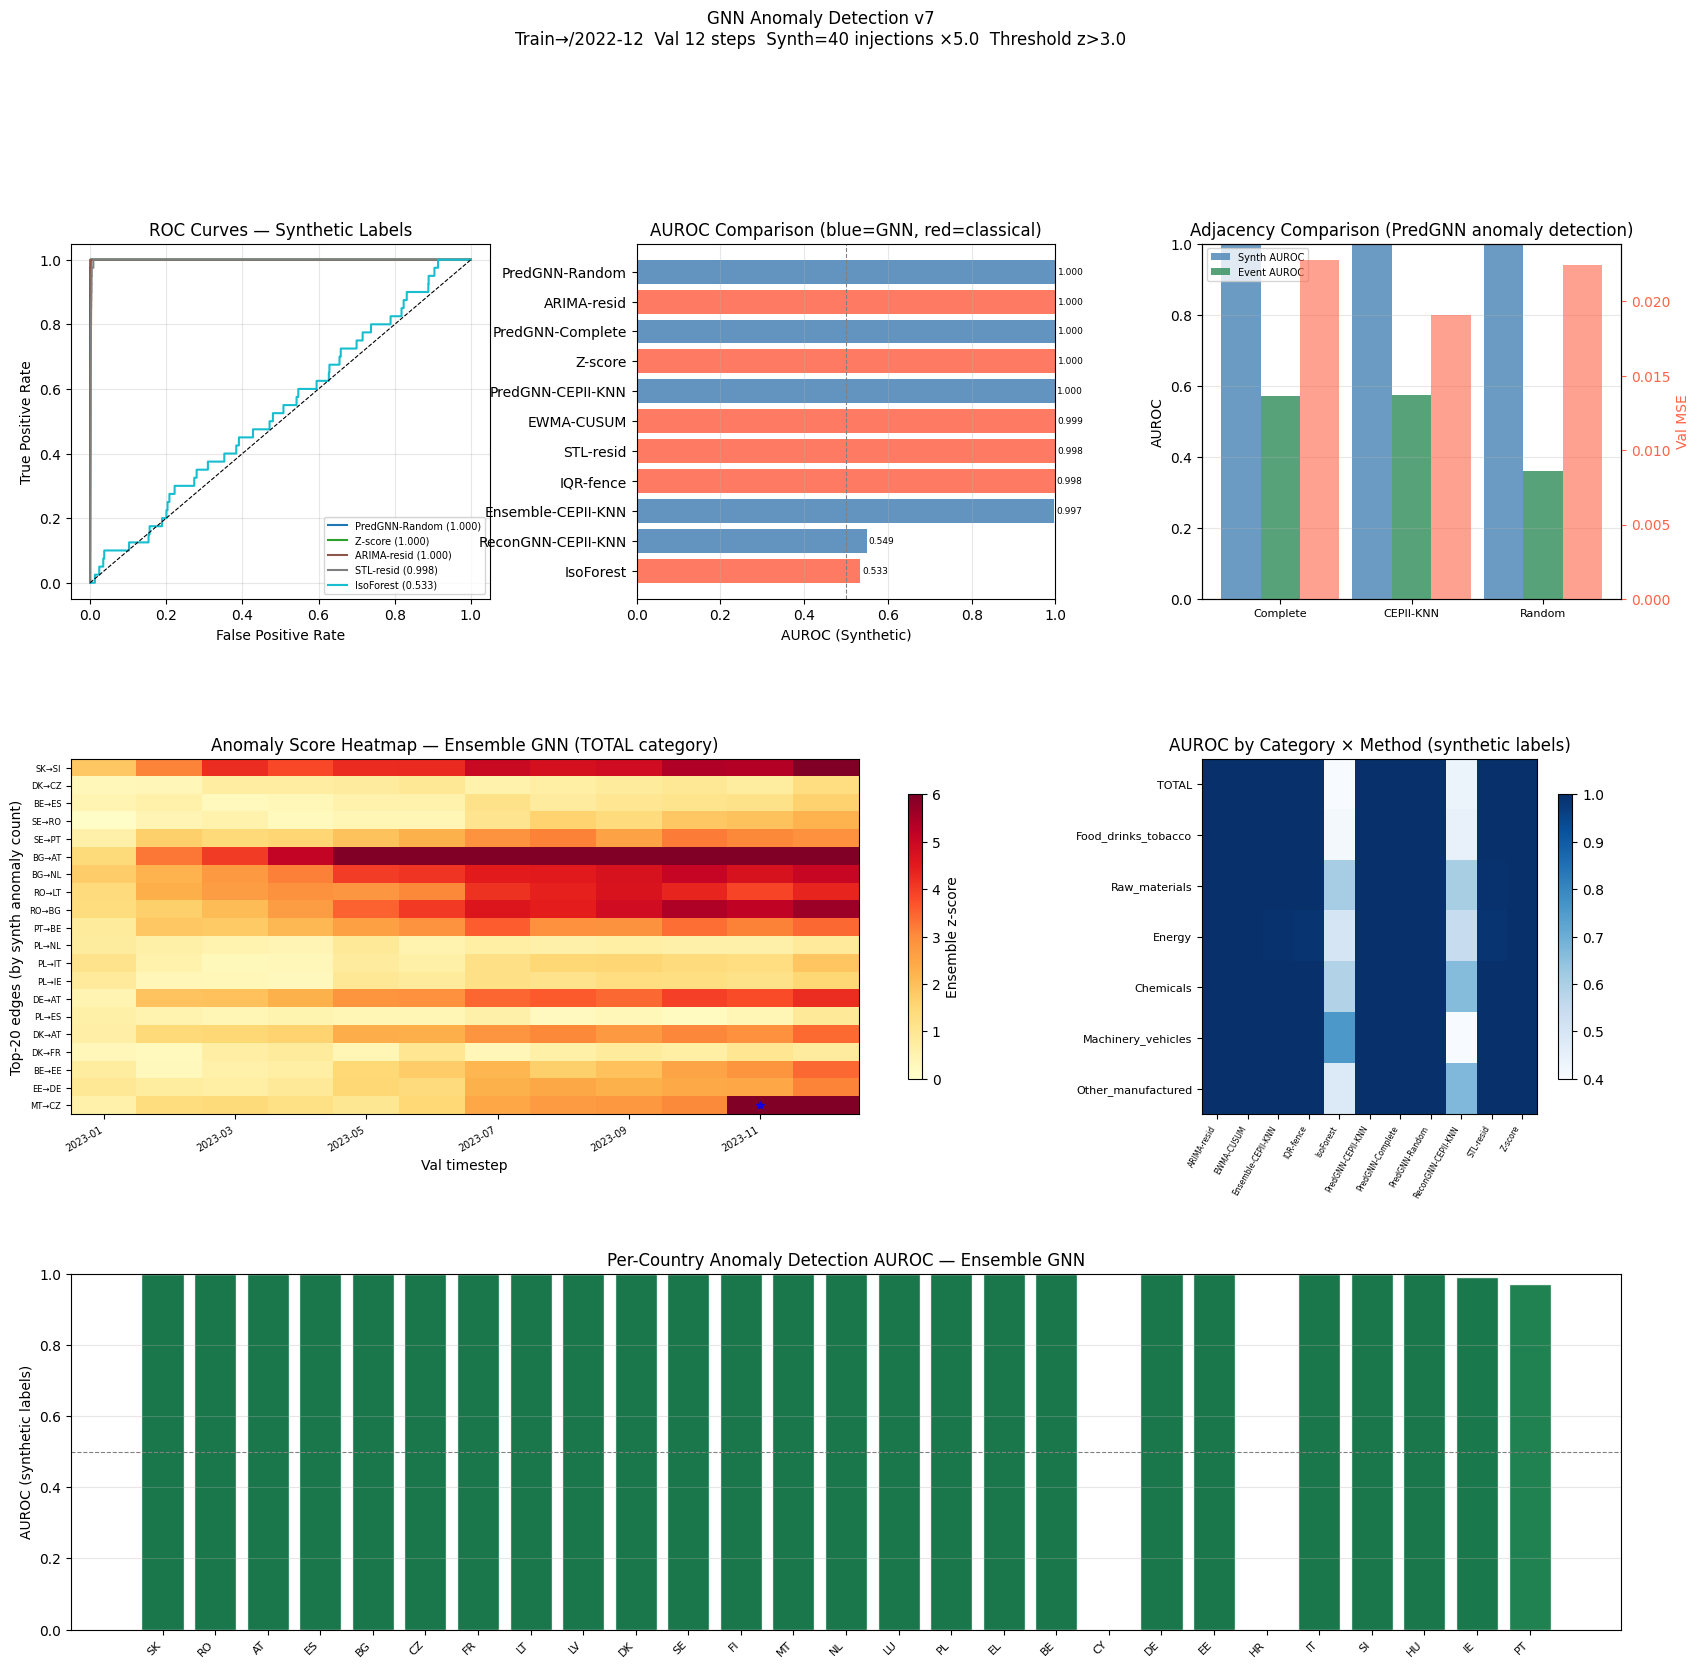

Saved: gnn_v7_anomaly.png

✓ v7 complete


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell M — Visualisation
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── M.1 ROC curves ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_roc = plt.cm.tab10(np.linspace(0,1,len(roc_curves)))
for (name, (fpr, tpr)), col in zip(roc_curves.items(), colors_roc):
    auc = eval_results.get(name, {}).get("synth", {}).get("auroc", 0)
    ax1.plot(fpr, tpr, label=f"{name} ({auc:.3f})", color=col, linewidth=1.5)
ax1.plot([0,1],[0,1],"k--", linewidth=0.8)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves — Synthetic Labels"); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# ── M.2 AUROC comparison bar ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
methods_sorted = sorted(eval_results.items(), key=lambda x: -(x[1]["synth"]["auroc"] or 0))
names_bar  = [n for n,_ in methods_sorted]
auroc_bar  = [r["synth"]["auroc"] or 0 for _,r in methods_sorted]
is_gnn     = ["GNN" in n or "Pred" in n or "Recon" in n or "Ensemble" in n
               for n in names_bar]
bar_colors = ["steelblue" if g else "tomato" for g in is_gnn]
bars = ax2.barh(names_bar[::-1], auroc_bar[::-1], color=bar_colors[::-1], alpha=0.85)
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random")
ax2.set_xlabel("AUROC (Synthetic)"); ax2.set_title("AUROC Comparison (blue=GNN, red=classical)")
ax2.set_xlim(0, 1); ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, auroc_bar[::-1]):
    ax2.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=6.5)

# ── M.3 Adjacency anomaly comparison ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
adj_names = list(adj_anomaly_results.keys())
synth_aucs = [adj_anomaly_results[a]["synth"]["auroc"] for a in adj_names]
event_aucs = [adj_anomaly_results[a]["event"]["auroc"] for a in adj_names]
val_mses   = [adj_anomaly_results[a]["val_mse"] for a in adj_names]
x = np.arange(len(adj_names))
w = 0.3
ax3.bar(x-w, synth_aucs, w, label="Synth AUROC", color="steelblue", alpha=0.8)
ax3.bar(x,   event_aucs, w, label="Event AUROC", color="seagreen",  alpha=0.8)
ax3b = ax3.twinx()
ax3b.bar(x+w, val_mses, w, label="Val MSE", color="tomato", alpha=0.6)
ax3b.set_ylabel("Val MSE", color="tomato"); ax3b.tick_params(axis="y", colors="tomato")
ax3.set_xticks(x); ax3.set_xticklabels(adj_names, fontsize=8)
ax3.set_ylabel("AUROC"); ax3.set_title("Adjacency Comparison (PredGNN anomaly detection)")
ax3.legend(loc="upper left", fontsize=7); ax3.grid(axis="y", alpha=0.3)
ax3.set_ylim(0, 1)

# ── M.4 Anomaly score heatmap over time × top edges ──────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
top_edges_by_synth = np.argsort(label_synth.sum(axis=(0,2)))[-20:][::-1]
score_slice = best_gnn_score[:, top_edges_by_synth, 0]   # TOTAL category
im = ax4.imshow(score_slice.T, aspect="auto", cmap="YlOrRd",
                vmin=0, vmax=min(ANOMALY_THRESH*2, np.nanpercentile(score_slice, 99)))
ax4.set_xlabel("Val timestep"); ax4.set_ylabel("Top-20 edges (by synth anomaly count)")
edge_labels = [f"{COUNTRIES[edge_pairs[e][0]]}→{COUNTRIES[edge_pairs[e][1]]}"
               for e in top_edges_by_synth]
ax4.set_yticks(range(20)); ax4.set_yticklabels(edge_labels, fontsize=6)
val_dates = [common_time[t+1].strftime("%Y-%m") for t in val_idx]
step = max(1, n_val//6)
ax4.set_xticks(range(0, n_val, step))
ax4.set_xticklabels(val_dates[::step], fontsize=7, rotation=30, ha="right")
plt.colorbar(im, ax=ax4, shrink=0.8, label="Ensemble z-score")
ax4.set_title(f"Anomaly Score Heatmap — Ensemble GNN (TOTAL category)")
# Overlay injected synthetic anomaly markers
for vi, e_idx, c_idx in synth_indices:
    e_pos = list(top_edges_by_synth).index(e_idx) if e_idx in top_edges_by_synth else None
    if e_pos is not None and c_idx == 0:
        ax4.plot(vi, e_pos, "b*", markersize=6, alpha=0.8)

# ── M.5 Per-category AUROC heatmap ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
cat_method_auroc = np.full((len(ALL_CATS), len(all_scores)), np.nan)
method_names_sorted = sorted(all_scores.keys())
for mi, mname in enumerate(method_names_sorted):
    sc_arr = all_scores[mname]
    for ci, cat in enumerate(ALL_CATS):
        sc = sc_arr[:,:,ci].reshape(-1); lb = label_synth[:,:,ci].reshape(-1).astype(int)
        ok = ~np.isnan(sc)
        if lb[ok].sum()>0:
            cat_method_auroc[ci, mi] = roc_auc_score(lb[ok], np.clip(sc[ok],0,np.percentile(sc[ok],99.9)))
im5 = ax5.imshow(cat_method_auroc, aspect="auto", cmap="Blues", vmin=0.4, vmax=1.0)
ax5.set_xticks(range(len(method_names_sorted)))
ax5.set_xticklabels(method_names_sorted, rotation=60, ha="right", fontsize=5.5)
ax5.set_yticks(range(N_CATS)); ax5.set_yticklabels(ALL_CATS, fontsize=8)
ax5.set_title("AUROC by Category × Method (synthetic labels)"); plt.colorbar(im5, ax=ax5, shrink=0.8)

# ── M.6 Per-country AUROC ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
countries_sorted = sorted(country_aucs.items(), key=lambda x: -(x[1] or 0))
cnames  = [c for c,_ in countries_sorted]
caucs   = [v or 0 for _,v in countries_sorted]
bar_c   = plt.cm.RdYlGn(np.array(caucs))
ax6.bar(cnames, caucs, color=bar_c, alpha=0.9, edgecolor="white")
ax6.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax6.set_ylabel("AUROC (synthetic labels)"); ax6.set_ylim(0,1)
ax6.set_title("Per-Country Anomaly Detection AUROC — Ensemble GNN")
ax6.set_xticklabels(cnames, rotation=45, ha="right", fontsize=8)
ax6.grid(axis="y", alpha=0.3)

train_end_str = TRAIN_END.strftime('%Y-%m')
plt.suptitle(
    f"GNN Anomaly Detection v7\n"
    f"Train→/{train_end_str}  Val {len(val_idx)} steps  "
    f"Synth={N_SYNTH} injections ×{SYNTH_MULT}  Threshold z>{ANOMALY_THRESH}",
    fontsize=12, y=1.01
)
plt.savefig("gnn_v7_anomaly.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: gnn_v7_anomaly.png")
print("\n✓ v7 complete")